In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
from persiantools.jdatetime import JalaliDate
import jalali_pandas
import pandas_ta  as ta
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tqdm import tqdm


In [2]:
df = pd.read_csv(r'../data/MCI_indicator.csv', encoding='utf-8')
df.head()

,open,high,low,close,volume,value,transaction_count,lastday_price,Gregorian_Date,Jalali_Date,...,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,BBL_20_2.0,BBM_20_2.0,BBU_20_2.0,BBB_20_2.0,BBP_20_2.0,STOCHk_14_3_3,STOCHd_14_3_3
0,42000.0,42200.0,42000.0,42001.0,546520,2.295462e+10,69,1000.0,2013-08-20,1392-05-29 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,42009.0,43500.0,42005.0,42142.0,161499,6.929039e+09,214,42001.0,2013-08-21,1392-05-30 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,43300.0,43300.0,42222.0,42191.0,110913,4.724576e+09,168,42142.0,2013-08-24,1392-06-02 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,42860.0,42860.0,42453.0,42213.0,67490,2.869908e+09,94,42191.0,2013-08-25,1392-06-03 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,42401.0,42501.0,42036.0,42214.0,160307,6.768045e+09,121,42213.0,2013-08-26,1392-06-04 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.drop(['open', 'high', 'low', 'close', 'volume', 'value', 'transaction_count',
       'lastday_price', 'Gregorian_Date', 'Jalali_Date', 'month',
       'day', 'weekday', 'close_diff'],axis=1,inplace=True)
df.dropna(axis=0,inplace=True)

In [4]:
X = df.drop(['close_diff_sign'],axis=1)
y = df[['close_diff_sign','year']]

X_train = X[X['year'] < 1403]
y_train = y[y['year'] < 1403]

X_test = X[X['year'] == 1403]
y_test = y[y['year'] == 1403]

X_train.drop(['year'],inplace=True,axis=1)
y_train.drop(['year'],inplace=True,axis=1)
X_test.drop(['year'],inplace=True,axis=1)
y_test.drop(['year'],inplace=True,axis=1)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19192\2746480843.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(['year'],inplace=True,axis=1)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19192\2746480843.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_train.drop(['year'],inplace=True,axis=1)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19192\2746480843.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.d

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Initial Metrics:
Accuracy: 0.4629
Precision: 0.4304
Recall: 0.9444
F1-score: 0.5913
AUC-ROC: 0.7191



Feature Elimination Progress:   0%|          | 0/40 [00:00<?, ?it/s]c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
Feature Elimination Progress:   2%|▎         | 1/40 [00:02<01:32,  2.38s/it]

After dropping feature: 'BBM_20_2.0'
Accuracy: 0.4514
Precision: 0.4250
Recall: 0.9444
F1-score: 0.5862
AUC-ROC: 0.6417



c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
Feature Elimination Progress:   5%|▌         | 2/40 [00:04<01:24,  2.23s/it]

...

After dropping feature: 'rsi_10'
Accuracy: 0.7543
Precision: 0.6706
Recall: 0.7917
F1-score: 0.7261
AUC-ROC: 0.8481



c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
Feature Elimination Progress:  98%|█████████▊| 39/40 [01:02<00:00,  1.12it/s]

After dropping feature: 'STOCHd_14_3_3'
Accuracy: 0.7371
Precision: 0.6667
Recall: 0.7222
F1-score: 0.6933
AUC-ROC: 0.8018



c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
Feature Elimination Progress: 100%|██████████| 40/40 [01:03<00:00,  1.59s/it]

After dropping feature: 'BBP_20_2.0'
Accuracy: 0.6800
Precision: 0.5976
Recall: 0.6806
F1-score: 0.6364
AUC-ROC: 0.7203



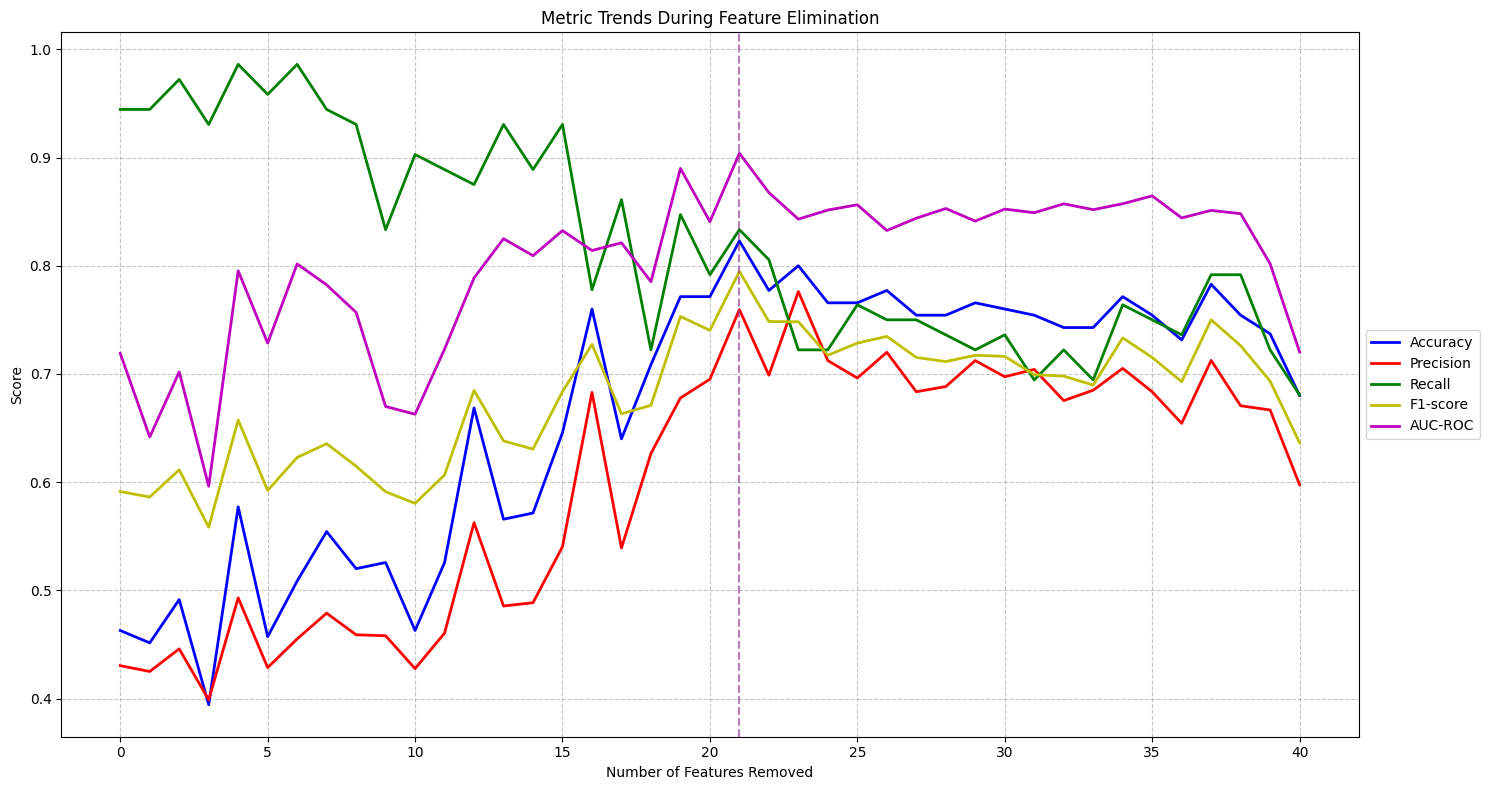


Best Performance Points:
Best Accuracy (0.8229) at 21 features removed
Best F1-Score (0.7947) at 21 features removed
Best AUC-ROC (0.9039) at 21 features removed

Dropped Features in Order:

1. BBM_20_2.0
Accuracy: 0.4514
Precision: 0.4250
Recall: 0.9444
F1-score: 0.5862
AUC-ROC: 0.6417

2. sma_20
Accuracy: 0.4914
Precision: 0.4459
Recall: 0.9722
F1-score: 0.6114
AUC-ROC: 0.7019

3. ema_10
Accuracy: 0.3943
Precision: 0.3988
Recall: 0.9306
F1-score: 0.5583
AUC-ROC: 0.5962

4. ema_60
Accuracy: 0.5771
Precision: 0.4931
Recall: 0.9861
F1-score: 0.6574
AUC-ROC: 0.7953

5. trima_20
Accuracy: 0.4571
Precision: 0.4286
Recall: 0.9583
F1-score: 0.5923
AUC-ROC: 0.7285

6. ema_40
Accuracy: 0.5086
Precision: 0.4551
Recall: 0.9861
F1-score: 0.6228
AUC-ROC: 0.8016

7. ema_5
Accuracy: 0.5543
Precision: 0.4789
Recall: 0.9444
F1-score: 0.6355
AUC-ROC: 0.7823

8. sma_40
Accuracy: 0.5200
Precision: 0.4589
Recall: 0.9306
F1-score: 0.6147
AUC-ROC: 0.7569

9. trima_10
Accuracy: 0.5257
Precision: 0.4580
Reca

In [5]:
# Change to RandomForestClassifier for binary classification
model = RandomForestClassifier(random_state=42)

# Track performance metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
auc_roc_scores = []
dropped_features = []

# Train the model with all features first
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # For ROC AUC

initial_accuracy = accuracy_score(y_test, y_pred)
initial_precision = precision_score(y_test, y_pred)
initial_recall = recall_score(y_test, y_pred)
initial_f1 = f1_score(y_test, y_pred)
initial_auc_roc = roc_auc_score(y_test, y_pred_proba)

print("Initial Metrics:")
print(f"Accuracy: {initial_accuracy:.4f}")
print(f"Precision: {initial_precision:.4f}")
print(f"Recall: {initial_recall:.4f}")
print(f"F1-score: {initial_f1:.4f}")
print(f"AUC-ROC: {initial_auc_roc:.4f}\n")

# Store initial metrics
accuracy_scores.append(initial_accuracy)
precision_scores.append(initial_precision)
recall_scores.append(initial_recall)
f1_scores.append(initial_f1)
auc_roc_scores.append(initial_auc_roc)

# Iteratively drop features based on importance
features = X_train.columns.tolist()

# Use tqdm to show progress bar for feature elimination
with tqdm(total=len(features)-1, desc="Feature Elimination Progress") as pbar:
    while len(features) > 1:
        # Train model and get feature importances
        model.fit(X_train[features], y_train)
        importances = model.feature_importances_

        # Find the least important feature
        least_important_idx = np.argmin(importances)
        feature_to_drop = features[least_important_idx]

        # Drop the feature
        features.remove(feature_to_drop)

        # Retrain model and evaluate
        model.fit(X_train[features], y_train)
        y_pred = model.predict(X_test[features])
        y_pred_proba = model.predict_proba(X_test[features])[:, 1]

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc_roc = roc_auc_score(y_test, y_pred_proba)

        # Store the metrics
        dropped_features.append(feature_to_drop)
        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_roc_scores.append(auc_roc)

        # Print current results
        print(f"After dropping feature: '{feature_to_drop}'")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-score: {f1:.4f}")
        print(f"AUC-ROC: {auc_roc:.4f}\n")

        # Update the progress bar
        pbar.update(1)

# Create the visualization
plt.figure(figsize=(15, 8))
x = range(len(accuracy_scores))

plt.plot(x, accuracy_scores, 'b-', label='Accuracy', linewidth=2)
plt.plot(x, precision_scores, 'r-', label='Precision', linewidth=2)
plt.plot(x, recall_scores, 'g-', label='Recall', linewidth=2)
plt.plot(x, f1_scores, 'y-', label='F1-score', linewidth=2)
plt.plot(x, auc_roc_scores, 'm-', label='AUC-ROC', linewidth=2)

plt.xlabel('Number of Features Removed')
plt.ylabel('Score')
plt.title('Metric Trends During Feature Elimination')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.7)

# Add vertical lines for best performance points
best_accuracy_idx = np.argmax(accuracy_scores)
best_f1_idx = np.argmax(f1_scores)
best_auc_idx = np.argmax(auc_roc_scores)

plt.axvline(x=best_accuracy_idx, color='b', linestyle='--', alpha=0.3)
plt.axvline(x=best_f1_idx, color='y', linestyle='--', alpha=0.3)
plt.axvline(x=best_auc_idx, color='m', linestyle='--', alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# Summary
print("\nBest Performance Points:")
print(f"Best Accuracy ({accuracy_scores[best_accuracy_idx]:.4f}) at {best_accuracy_idx} features removed")
print(f"Best F1-Score ({f1_scores[best_f1_idx]:.4f}) at {best_f1_idx} features removed")
print(f"Best AUC-ROC ({auc_roc_scores[best_auc_idx]:.4f}) at {best_auc_idx} features removed")

print("\nDropped Features in Order:")
for i, feature in enumerate(dropped_features):
    print(f"\n{i+1}. {feature}")
    print(f"Accuracy: {accuracy_scores[i+1]:.4f}")
    print(f"Precision: {precision_scores[i+1]:.4f}")
    print(f"Recall: {recall_scores[i+1]:.4f}")
    print(f"F1-score: {f1_scores[i+1]:.4f}")
    print(f"AUC-ROC: {auc_roc_scores[i+1]:.4f}")

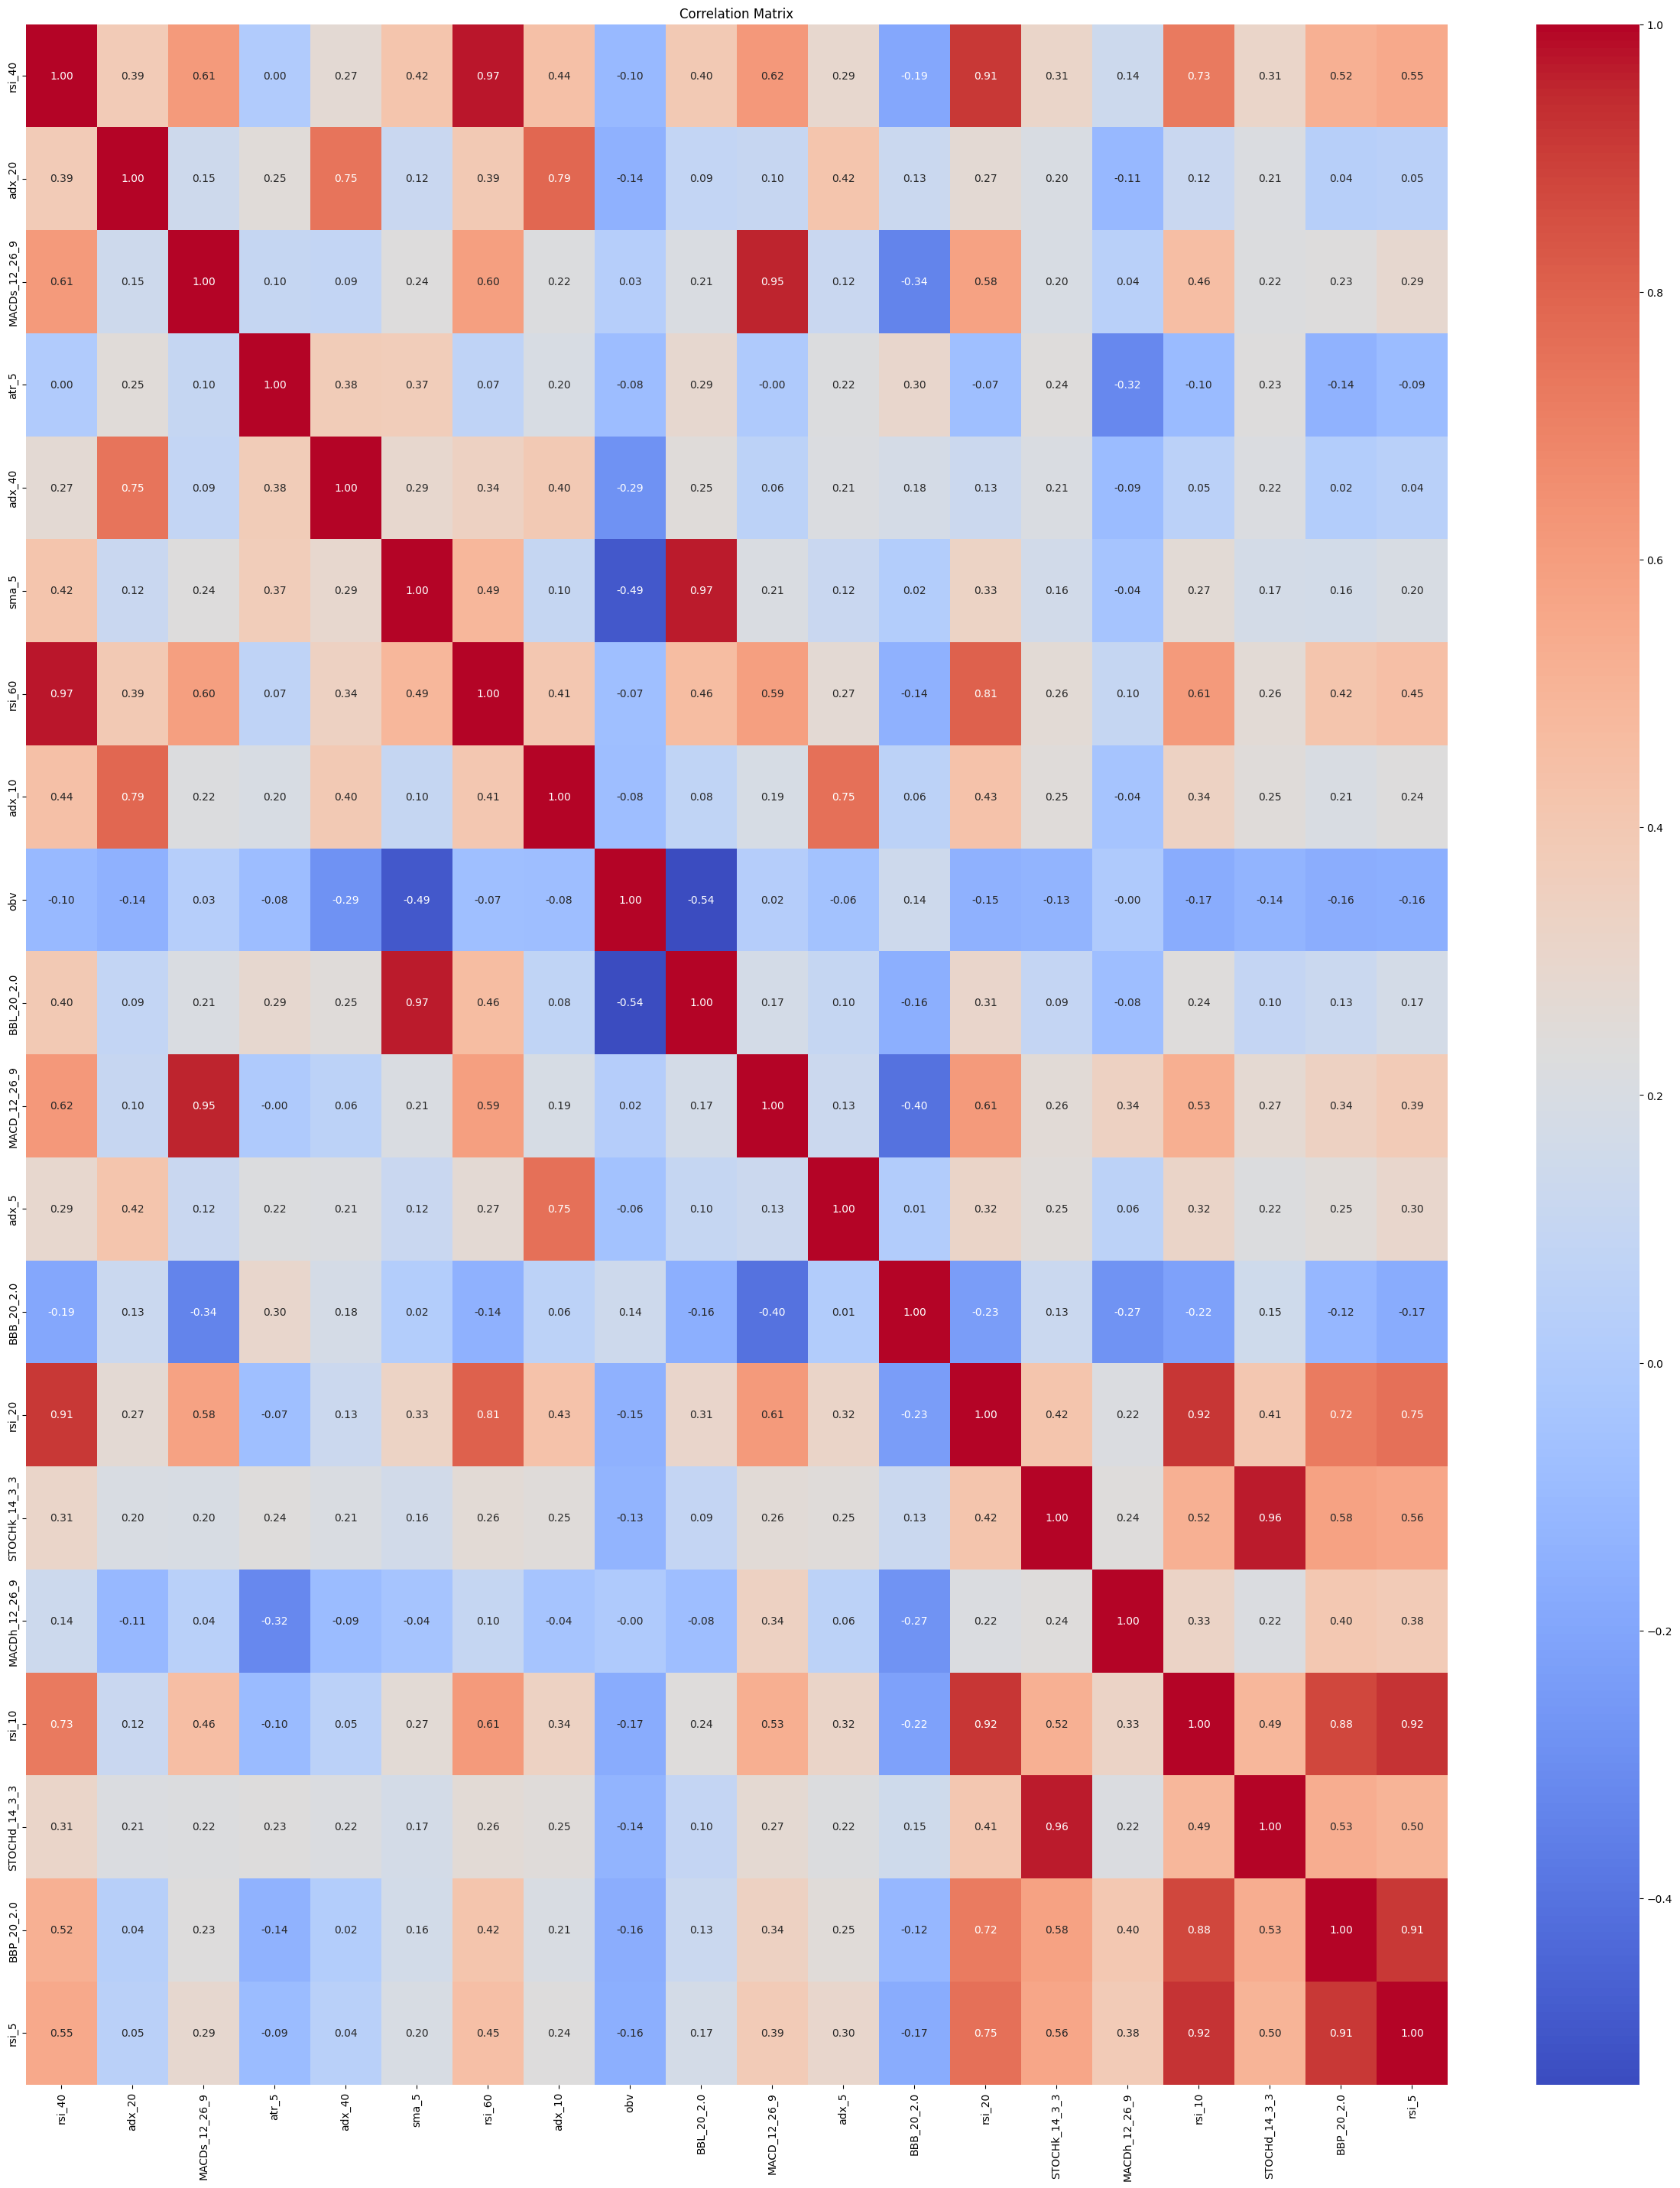

In [8]:
corr = X_selected.corr(numeric_only=True)

# ذخیره‌ی ماتریس همبستگی به عنوان تصویر
plt.figure(figsize=(30, 35))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Correlation Matrix")
# plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

# List of selected features
selected_features = [
    'rsi_40', 'adx_20', 'MACDs_12_26_9', 'atr_5', 'adx_40',
    'sma_5', 'rsi_60',
    'adx_10', 'obv',
    'BBL_20_2.0', 'MACD_12_26_9',
    'adx_5','BBB_20_2.0','rsi_20','STOCHk_14_3_3','MACDh_12_26_9',
    'rsi_10','STOCHd_14_3_3','BBP_20_2.0','rsi_5'
]

# Create the model with selected features
X_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Initialize and train the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Fit the model
rf_model.fit(X_selected, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_selected)
y_pred_proba = rf_model.predict_proba(X_test_selected)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

# Print detailed results
print("Random Forest Model Performance Metrics:")
print("-" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")
print("\nConfusion Matrix:")
print("-" * 40)
print(confusion_matrix(y_test, y_pred))
print("\nDetailed Classification Report:")
print("-" * 40)
print(classification_report(y_test, y_pred))

# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

print("\nFeature Importance:")
print("-" * 40)
for idx, row in feature_importance.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Model Performance Metrics:
----------------------------------------
Accuracy:  0.8057
Precision: 0.7375
Recall:    0.8194
F1-score:  0.7763
AUC-ROC:   0.8703

Confusion Matrix:
----------------------------------------
[[82 21]
 [13 59]]

Detailed Classification Report:
----------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       103
           1       0.74      0.82      0.78        72

    accuracy                           0.81       175
   macro avg       0.80      0.81      0.80       175
weighted avg       0.81      0.81      0.81       175


Feature Importance:
----------------------------------------
rsi_5: 0.1706
BBP_20_2.0: 0.0899
rsi_10: 0.0729
STOCHd_14_3_3: 0.0586
STOCHk_14_3_3: 0.0521
MACDh_12_26_9: 0.0485
rsi_20: 0.0415
MACD_12_26_9: 0.0392
adx_10: 0.0390
adx_5: 0.0386
rsi_40: 0.0378
BBB_20_2.0: 0.0367
BBL_20_2.0: 0.0357
atr_5: 0.0355
obv: 0.0347
MACDs_12_26_9: 0.0344
sma_5: